# Notebook 13. Geographic-Exclusion `850 hPa` Temperature-Gradient Sensitivity

This notebook tests a more direct terrain-interference fix for the `850 hPa` temperature-gradient feature.

Why this notebook exists:

- the unmasked `850 hPa` temperature-gradient composite in `Notebook 10` still looked strongly terrain-linked even after display-only colorbar tightening
- simply **dropping** the `T850` feature in `Notebook 11` changed too much of the `k = 3` clustering story
- the `surface_pressure >= 900 hPa` screen in `Notebook 12` was credible but too permissive, so it changed essentially nothing in the feature or the clustering
- the next sensitivity is therefore to keep the feature, but explicitly remove the coastal Russian mountain strip bordering the Sea of Japan before the front-box maximum is computed

What changes here:

- only the `front_box_max_temp_gradient_850_tminus12_to_tplus12` feature is rebuilt
- a fixed set of Russian-coastal exclusion boxes is applied to the `850 hPa |grad T|` grid before the front-box maximum is computed
- the other three clustering features stay unchanged

What does **not** change here:

- `925 hPa` signed-divergence feature definitions stay unchanged
- `850 hPa` `z` anomaly logic stays unchanged
- `925 hPa` Sea-of-Japan vorticity stays unchanged
- no `300 hPa` climatology or composite rebuild is done in this notebook

Checkpointing note:

- the event-level geographically excluded `T850` feature table is checkpointed to Drive while it is being built so that a dropped connection does not lose all progress
- the notebook includes a one-event sanity check before the long event loop so a bad exclusion design should fail fast


In [1]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Mounted at /content/drive
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog


In [2]:
from itertools import permutations
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import BoundingBox, HOKKAIDO_FRONT_BOX, OBJECTIVE_SUBTYPE_DOMAIN
from jpcz_catalog.diagnostics import compute_temperature_gradient_magnitude, load_offset_snapshot
from jpcz_catalog.era5 import open_arco_era5
from jpcz_catalog.subtypes import (
    assign_hierarchical_clusters,
    compute_mean_silhouette_score,
    evaluate_hierarchical_cluster_solutions,
    standardize_feature_table,
)

RUN_EXPORT_DIR_08 = Path("outputs/verification/objective_subtype_runs")
RUN_EXPORT_DIR_08.mkdir(parents=True, exist_ok=True)
SENSITIVITY_EXPORT_DIR = Path("outputs/verification/objective_subtype_t850_russian_coastal_exclusion_sensitivity")
SENSITIVITY_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_subtype_t850_russian_coastal_exclusion_sensitivity_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTERED_K3_PATH = RUN_EXPORT_DIR_08 / "clustered_events_k3.csv"
PRIMARY_CLUSTER_COLUMN = "cluster_ward_3"
PRIMARY_CLUSTER_K = 3
EXCLUDED_CLUSTER_COLUMN_RAW = "cluster_ward_3_russian_coastal_excluded_t850_raw"
EXCLUDED_CLUSTER_COLUMN = "cluster_ward_3_russian_coastal_excluded_t850"
DROPPED_FEATURE = "front_box_max_temp_gradient_850_tminus12_to_tplus12"
EXCLUDED_FEATURE_COLUMN = "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded"

FULL_FEATURE_COLUMNS = [
    "coastal_to_jpcz_mean_divergence_ratio",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    DROPPED_FEATURE,
    "sea_of_japan_mean_vorticity_peak_925",
]
EXCLUDED_FEATURE_COLUMNS = [
    "coastal_to_jpcz_mean_divergence_ratio",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    EXCLUDED_FEATURE_COLUMN,
    "sea_of_japan_mean_vorticity_peak_925",
]
CLUSTER_COUNT_OPTIONS = [2, 3, 4]
SAVE_PLOTS = True
ERA5_TIME_CHUNK = 48
FORCE_REBUILD_GEO_EXCLUDED_T850 = False
CHECKPOINT_EVERY_EVENTS = 5
OFFSET_HOURS = (-12, 0, 12)

# Focused exclusion boxes for the coastal Russian mountain strip bordering the Sea of Japan.
# These intentionally avoid masking Hokkaido or northern Honshu so the sensitivity
# isolates the Russian coastal terrain signal as cleanly as possible.
GEOGRAPHIC_EXCLUSION_BOXES = (
    BoundingBox(lon_min=130.5, lon_max=135.5, lat_min=42.0, lat_max=45.0),
    BoundingBox(lon_min=133.5, lon_max=139.5, lat_min=44.0, lat_max=47.25),
)
GEOGRAPHIC_EXCLUSION_LABELS = (
    "Southwestern Russian coastal mountain strip",
    "Northeastern Russian coastal mountain strip",
)

EXCLUDED_EVENT_FEATURES_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_event_features.csv"
EXCLUDED_EVENT_FEATURES_PARTIAL_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_event_features_partial.csv"
EXCLUDED_SWITCHING_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_switching_summary.csv"
EXCLUDED_CROSSTAB_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_cluster_crosstab.csv"
EXCLUDED_COUNTS_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_cluster_counts.csv"
EXCLUDED_MEDIANS_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_cluster_medians.csv"
EXCLUDED_SOLUTION_SUMMARY_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_solution_summary.csv"
EXCLUDED_QUALITY_SCAN_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_quality_scan.csv"
EXCLUDED_VARIANCE_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_pca_variance.csv"
EXCLUDED_LOADINGS_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_pca_loadings.csv"
EXCLUDED_DRIVERS_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_pca_drivers.csv"
EXCLUDED_CLUSTERED_EVENTS_PATH = SENSITIVITY_EXPORT_DIR / "clustered_events_k3_russian_coastal_excluded_t850.csv"
EXCLUDED_FEATURE_COMPARISON_PATH = SENSITIVITY_EXPORT_DIR / "k3_russian_coastal_excluded_t850_feature_comparison_by_current_cluster.csv"

PCA_SCATTER_PATH = PLOT_DIR / "k3_pca_scatter_full_vs_russian_coastal_excluded_t850.png"
PCA_VARIANCE_PLOT_PATH = PLOT_DIR / "k3_pca_variance_full_vs_russian_coastal_excluded_t850.png"
T850_COMPARE_PLOT_PATH = PLOT_DIR / "k3_t850_unmasked_vs_russian_coastal_excluded_cluster_boxplots.png"

FEATURE_LABELS = {
    "coastal_to_jpcz_mean_divergence_ratio": "Coastal/JPCZ signed-divergence ratio",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12": "Hokkaido minimum z850 anomaly",
    DROPPED_FEATURE: "Front-box maximum |grad T850|",
    EXCLUDED_FEATURE_COLUMN: "Front-box maximum |grad T850| (Russian coastal exclusion)",
    "sea_of_japan_mean_vorticity_peak_925": "Sea of Japan mean 925 hPa vorticity",
}
FEATURE_UNITS = {
    "coastal_to_jpcz_mean_divergence_ratio": "unitless",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12": "gpm",
    DROPPED_FEATURE: "K (100 km)^-1",
    EXCLUDED_FEATURE_COLUMN: "K (100 km)^-1",
    "sea_of_japan_mean_vorticity_peak_925": "1e-5 s^-1",
}


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None


def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True


def axis_label(column_name: str) -> str:
    label = FEATURE_LABELS.get(column_name, column_name)
    units = FEATURE_UNITS.get(column_name, "")
    if units and units != "unitless":
        return f"{label}\n[{units}]"
    return label


def cluster_count_table(labels: pd.Series) -> pd.DataFrame:
    counts = labels.value_counts().sort_index()
    max_count = int(counts.max())
    rows = []
    for cluster_id, n_events in counts.items():
        if n_events == max_count:
            size_rank = 1
            size_descriptor = "largest subgroup"
        elif n_events == int(counts.min()):
            size_rank = int((counts.rank(method="dense", ascending=False)).loc[cluster_id])
            size_descriptor = "smallest subgroup"
        else:
            size_rank = int((counts.rank(method="dense", ascending=False)).loc[cluster_id])
            size_descriptor = "second-largest subgroup" if size_rank == 2 else f"rank {size_rank} subgroup"
        rows.append(
            {
                "cluster_id": int(cluster_id),
                "n_events": int(n_events),
                "size_rank": size_rank,
                "size_descriptor": size_descriptor,
                "cluster_label": f"Cluster {int(cluster_id)}: n={int(n_events)} ({size_descriptor})",
            }
        )
    return pd.DataFrame(rows)


def best_cluster_label_mapping(reference_labels: pd.Series, candidate_labels: pd.Series):
    reference = reference_labels.astype(int)
    candidate = candidate_labels.astype(int).reindex(reference.index)
    unique_reference = sorted(reference.dropna().unique().tolist())
    unique_candidate = sorted(candidate.dropna().unique().tolist())
    if len(unique_reference) != len(unique_candidate):
        raise ValueError(
            "Expected the same number of clusters in the reference and candidate solutions, "
            f"got {unique_reference} versus {unique_candidate}."
        )

    best_mapping = None
    best_matches = -1
    for perm in permutations(unique_reference, len(unique_candidate)):
        mapping = dict(zip(unique_candidate, perm))
        mapped = candidate.map(mapping)
        match_count = int((mapped == reference).sum())
        if match_count > best_matches:
            best_matches = match_count
            best_mapping = mapping
    return best_mapping, best_matches


def compute_pca_diagnostics(feature_df: pd.DataFrame, feature_columns: list[str]):
    standardized_df, feature_means, feature_stds = standardize_feature_table(feature_df.copy(), columns=feature_columns)
    valid = standardized_df.dropna(axis=0, how="any")
    if valid.empty:
        raise ValueError("No complete rows are available for PCA.")

    matrix = valid.to_numpy(dtype=float)
    _, singular_values, vt = np.linalg.svd(matrix, full_matrices=False)
    n_components = min(3, matrix.shape[1])
    components = vt[:n_components]
    scores = matrix @ components.T

    total_variance = float((singular_values ** 2).sum())
    explained_variance_ratio = (singular_values[:n_components] ** 2) / total_variance

    score_df = pd.DataFrame(
        scores,
        index=valid.index,
        columns=[f"PC{i + 1}" for i in range(n_components)],
    )
    variance_df = pd.DataFrame(
        {
            "principal_component": [f"PC{i + 1}" for i in range(n_components)],
            "explained_variance_ratio": explained_variance_ratio,
            "explained_variance_percent": explained_variance_ratio * 100.0,
            "cumulative_explained_variance_ratio": np.cumsum(explained_variance_ratio),
            "cumulative_explained_variance_percent": np.cumsum(explained_variance_ratio) * 100.0,
        }
    )
    loadings_df = pd.DataFrame(
        components.T,
        index=feature_columns,
        columns=[f"PC{i + 1}" for i in range(n_components)],
    ).reset_index().rename(columns={"index": "feature"})
    loadings_long_df = loadings_df.melt(id_vars="feature", var_name="principal_component", value_name="loading")
    loadings_long_df["feature_label"] = loadings_long_df["feature"].map(FEATURE_LABELS)

    driver_rows = []
    for pc_name in variance_df["principal_component"]:
        component_subset = loadings_long_df.loc[loadings_long_df["principal_component"] == pc_name].copy()
        component_subset["abs_loading"] = component_subset["loading"].abs()
        top_two = component_subset.sort_values("abs_loading", ascending=False).head(2).reset_index(drop=True)
        driver_rows.append(
            {
                "principal_component": pc_name,
                "explained_variance_percent": float(
                    variance_df.loc[variance_df["principal_component"] == pc_name, "explained_variance_percent"].iloc[0]
                ),
                "top_driver_feature": top_two.loc[0, "feature"],
                "top_driver_label": top_two.loc[0, "feature_label"],
                "top_driver_loading": float(top_two.loc[0, "loading"]),
                "second_driver_feature": top_two.loc[1, "feature"] if len(top_two) > 1 else "",
                "second_driver_label": top_two.loc[1, "feature_label"] if len(top_two) > 1 else "",
                "second_driver_loading": float(top_two.loc[1, "loading"]) if len(top_two) > 1 else np.nan,
            }
        )
    driver_df = pd.DataFrame(driver_rows)
    return standardized_df, score_df, variance_df, loadings_long_df, driver_df, feature_means, feature_stds


def _box_max(field: xr.DataArray, box) -> float:
    boxed = field.sel(
        longitude=slice(box.lon_min, box.lon_max),
        latitude=slice(box.lat_max, box.lat_min),
    )
    return float(boxed.max(skipna=True).values)


def safe_nanmax(values) -> float:
    array = np.asarray(values, dtype=float)
    if array.size == 0 or np.all(np.isnan(array)):
        return float("nan")
    return float(np.nanmax(array))


def strip_nonspatial_coords(field: xr.DataArray) -> xr.DataArray:
    drop_coords = [coord_name for coord_name in field.coords if coord_name not in {"latitude", "longitude"}]
    if drop_coords:
        field = field.reset_coords(names=drop_coords, drop=True)
    return field


def exclusion_box_table() -> pd.DataFrame:
    rows = []
    for label, box in zip(GEOGRAPHIC_EXCLUSION_LABELS, GEOGRAPHIC_EXCLUSION_BOXES):
        rows.append(
            {
                "label": label,
                "lon_min": box.lon_min,
                "lon_max": box.lon_max,
                "lat_min": box.lat_min,
                "lat_max": box.lat_max,
            }
        )
    return pd.DataFrame(rows)


def build_geographic_keep_mask(target_field: xr.DataArray) -> xr.DataArray:
    lat_vals = np.asarray(target_field.latitude.values, dtype=float)
    lon_vals = np.asarray(target_field.longitude.values, dtype=float)
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
    keep_mask = np.ones((len(lat_vals), len(lon_vals)), dtype=bool)

    for box in GEOGRAPHIC_EXCLUSION_BOXES:
        in_box = (
            (lon2d >= box.lon_min)
            & (lon2d <= box.lon_max)
            & (lat2d >= box.lat_min)
            & (lat2d <= box.lat_max)
        )
        keep_mask &= ~in_box

    mask = xr.DataArray(
        keep_mask,
        coords={"latitude": target_field.latitude, "longitude": target_field.longitude},
        dims=("latitude", "longitude"),
        name="geographic_keep_mask",
    )
    mask.attrs["meaning"] = "True outside the focused Russian coastal terrain-interference exclusion boxes"
    return mask


In [3]:
for path_to_restore in [CLUSTERED_K3_PATH]:
    if not path_to_restore.exists():
        restore_from_drive_cache(CLUSTERED_K3_PATH)

clustered_k3_df = pd.read_csv(CLUSTERED_K3_PATH)
clustered_k3_df = add_japan_local_time_columns(clustered_k3_df)
if PRIMARY_CLUSTER_COLUMN not in clustered_k3_df.columns:
    cluster_cols = [column for column in clustered_k3_df.columns if column.startswith("cluster_")]
    raise RuntimeError(f"Expected {PRIMARY_CLUSTER_COLUMN} in clustered_events_k3.csv, found {cluster_cols}")

current_cluster_labels = clustered_k3_df[PRIMARY_CLUSTER_COLUMN].astype(int)
current_cluster_counts_df = cluster_count_table(current_cluster_labels)
current_cluster_label_lookup = current_cluster_counts_df.set_index("cluster_id")["cluster_label"].to_dict()

print("Loaded current clustered k=3 rerun table from Notebook 08 outputs")
display(current_cluster_counts_df)
print("\nThis notebook keeps the current 4-feature solution as the baseline and replaces only the T850 frontality metric with a Russian-coastal geographically excluded version.")


Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/clustered_events_k3.csv -> outputs/verification/objective_subtype_runs/clustered_events_k3.csv
Loaded current clustered k=3 rerun table from Notebook 08 outputs


,cluster_id,n_events,size_rank,size_descriptor,cluster_label
0,1,134,1,largest subgroup,Cluster 1: n=134 (largest subgroup)
1,2,20,3,smallest subgroup,Cluster 2: n=20 (smallest subgroup)
2,3,47,2,second-largest subgroup,Cluster 3: n=47 (second-largest subgroup)



This notebook keeps the current 4-feature solution as the baseline and replaces only the T850 frontality metric with a Russian-coastal geographically excluded version.


In [4]:
if 'era5_runtime_ds' not in globals():
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})

sample_event_row = clustered_k3_df.iloc[0].copy()
sample_temp_snapshot_850 = load_offset_snapshot(
    era5_runtime_ds,
    sample_event_row["event_peak"],
    offset_hours=0,
    variables=["temperature"],
    domain=OBJECTIVE_SUBTYPE_DOMAIN,
    level=850,
)
sample_temp_grad = compute_temperature_gradient_magnitude(sample_temp_snapshot_850)
sample_temp_grad_display = (sample_temp_grad * float(sample_temp_grad.attrs.get("display_scale_factor", 1.0))).rename("temperature_gradient_display")
sample_keep_mask = build_geographic_keep_mask(sample_temp_grad_display)

mask_summary_df = pd.DataFrame(
    {
        "metric": [
            "sample event peak",
            "number of exclusion boxes",
            "fraction of full domain kept by exclusion mask",
            "fraction of Hokkaido front box kept by exclusion mask",
        ],
        "value": [
            str(pd.Timestamp(sample_event_row["event_peak"])),
            len(GEOGRAPHIC_EXCLUSION_BOXES),
            round(float(sample_keep_mask.mean().values), 3),
            round(
                float(
                    sample_keep_mask.sel(
                        longitude=slice(HOKKAIDO_FRONT_BOX.lon_min, HOKKAIDO_FRONT_BOX.lon_max),
                        latitude=slice(HOKKAIDO_FRONT_BOX.lat_max, HOKKAIDO_FRONT_BOX.lat_min),
                    ).mean().values
                ),
                3,
            ),
        ],
    }
)
print("Russian-coastal geographic-exclusion T850 mask summary")
display(mask_summary_df)
print("\nRussian coastal exclusion boxes")
display(exclusion_box_table())


Russian-coastal geographic-exclusion T850 mask summary


,metric,value
0,sample event peak,2000-01-05 23:00:00
1,number of exclusion boxes,2
2,fraction of full domain kept by exclusion mask,0.891
3,fraction of Hokkaido front box kept by exclusi...,0.869



Russian coastal exclusion boxes


,label,lon_min,lon_max,lat_min,lat_max
0,Southwestern Russian coastal mountain strip,130.5,135.5,42.0,45.00
1,Northeastern Russian coastal mountain strip,133.5,139.5,44.0,47.25


In [5]:
if 'mask_summary_df' not in globals() or 'clustered_k3_df' not in globals():
    raise RuntimeError(
        "Run the geographic-exclusion summary cell first so the exclusion boxes and clustered table are defined before the sanity check."
    )

if 'era5_runtime_ds' not in globals():
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})

sample_event_row = clustered_k3_df.iloc[0].copy()
sample_temp_snapshot_850 = load_offset_snapshot(
    era5_runtime_ds,
    sample_event_row["event_peak"],
    offset_hours=0,
    variables=["temperature"],
    domain=OBJECTIVE_SUBTYPE_DOMAIN,
    level=850,
)
sample_temp_grad = compute_temperature_gradient_magnitude(sample_temp_snapshot_850)
sample_temp_grad_display = (sample_temp_grad * float(sample_temp_grad.attrs.get("display_scale_factor", 1.0))).rename("temperature_gradient_display")
sample_keep_mask = build_geographic_keep_mask(sample_temp_grad_display)
sample_excluded_temp_grad = sample_temp_grad_display.where(sample_keep_mask)

sample_front_box_unmasked = sample_temp_grad_display.sel(
    longitude=slice(HOKKAIDO_FRONT_BOX.lon_min, HOKKAIDO_FRONT_BOX.lon_max),
    latitude=slice(HOKKAIDO_FRONT_BOX.lat_max, HOKKAIDO_FRONT_BOX.lat_min),
)
sample_front_box_excluded = sample_excluded_temp_grad.sel(
    longitude=slice(HOKKAIDO_FRONT_BOX.lon_min, HOKKAIDO_FRONT_BOX.lon_max),
    latitude=slice(HOKKAIDO_FRONT_BOX.lat_max, HOKKAIDO_FRONT_BOX.lat_min),
)

sample_sanity_df = pd.DataFrame(
    {
        "metric": [
            "sample event peak",
            "sample current cluster",
            "sample offset hours",
            "keep fraction full domain",
            "keep fraction Hokkaido front box",
            "sample front-box unmasked max [K (100 km)^-1]",
            "sample front-box Russian-coastal excluded max [K (100 km)^-1]",
            "sample front-box finite-cell count after exclusion",
        ],
        "value": [
            str(pd.Timestamp(sample_event_row["event_peak"])),
            int(sample_event_row[PRIMARY_CLUSTER_COLUMN]),
            0,
            round(float(sample_keep_mask.mean().values), 3),
            round(float(sample_front_box_excluded.notnull().mean().values), 3),
            round(float(sample_front_box_unmasked.max(skipna=True).values), 3),
            round(float(sample_front_box_excluded.max(skipna=True).values), 3),
            int(sample_front_box_excluded.notnull().sum().values),
        ],
    }
)
print("One-event Russian-coastal geographic-exclusion T850 sanity check before the full event loop")
display(sample_sanity_df)
if int(sample_front_box_excluded.notnull().sum().values) <= 0:
    raise RuntimeError(
        "The sanity-check event has zero valid excluded-mask cells in the Hokkaido front box. "
        "Do not run the full excluded-feature loop until the exclusion boxes are corrected."
    )


One-event Russian-coastal geographic-exclusion T850 sanity check before the full event loop


,metric,value
0,sample event peak,2000-01-05 23:00:00
1,sample current cluster,1
2,sample offset hours,0
3,keep fraction full domain,0.891
4,keep fraction Hokkaido front box,0.869
5,sample front-box unmasked max [K (100 km)^-1],7.803
6,sample front-box Russian-coastal excluded max ...,5.469
7,sample front-box finite-cell count after exclu...,1290


In [6]:
for path_to_restore in [EXCLUDED_EVENT_FEATURES_PATH, EXCLUDED_EVENT_FEATURES_PARTIAL_PATH]:
    if not path_to_restore.exists():
        restore_from_drive_cache(path_to_restore)

if 'era5_runtime_ds' not in globals():
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})

existing_excluded_df = None
if EXCLUDED_EVENT_FEATURES_PATH.exists() and not FORCE_REBUILD_GEO_EXCLUDED_T850:
    existing_excluded_df = pd.read_csv(EXCLUDED_EVENT_FEATURES_PATH)
    print("Loaded cached final Russian-coastal geographically excluded T850 event feature table")
elif EXCLUDED_EVENT_FEATURES_PARTIAL_PATH.exists() and not FORCE_REBUILD_GEO_EXCLUDED_T850:
    existing_excluded_df = pd.read_csv(EXCLUDED_EVENT_FEATURES_PARTIAL_PATH)
    print("Loaded cached partial Russian-coastal geographically excluded T850 event feature table")

if existing_excluded_df is not None and not existing_excluded_df.empty:
    existing_excluded_df["event_row_index"] = pd.to_numeric(existing_excluded_df["event_row_index"], errors="coerce").astype("Int64")
    existing_excluded_df[EXCLUDED_FEATURE_COLUMN] = pd.to_numeric(existing_excluded_df[EXCLUDED_FEATURE_COLUMN], errors="coerce")
    finite_cached = int(existing_excluded_df[EXCLUDED_FEATURE_COLUMN].notna().sum())
    print(f"Cached Russian-coastal geographically excluded T850 rows with finite feature values: {finite_cached}/{len(existing_excluded_df)}")
    if finite_cached == 0:
        print("Cached Russian-coastal geographically excluded T850 table has zero finite values, so it will be ignored and rebuilt.")
        existing_excluded_df = None

processed_records = []
processed_event_indices = set()
if existing_excluded_df is not None and not existing_excluded_df.empty:
    processed_records = existing_excluded_df.to_dict(orient="records")
    processed_event_indices = {int(value) for value in existing_excluded_df["event_row_index"].dropna().tolist()}


def compute_geo_excluded_t850_feature_for_event(row: pd.Series) -> float:
    feature_values = []
    for offset_hours in OFFSET_HOURS:
        temp_snapshot_850 = load_offset_snapshot(
            era5_runtime_ds,
            row["event_peak"],
            offset_hours=offset_hours,
            variables=["temperature"],
            domain=OBJECTIVE_SUBTYPE_DOMAIN,
            level=850,
        )
        temp_grad = compute_temperature_gradient_magnitude(temp_snapshot_850)
        temp_grad_display = (temp_grad * float(temp_grad.attrs.get("display_scale_factor", 1.0))).rename("temperature_gradient_display")
        keep_mask = build_geographic_keep_mask(temp_grad_display)
        excluded_temp_grad = temp_grad_display.where(keep_mask)
        feature_values.append(_box_max(excluded_temp_grad, HOKKAIDO_FRONT_BOX))
    return safe_nanmax(feature_values)

remaining_rows = clustered_k3_df.loc[~clustered_k3_df.index.isin(processed_event_indices)].copy()
print(f"Russian-coastal geographically excluded T850 feature progress before this run: {len(processed_event_indices)}/{len(clustered_k3_df)} events")

for _, (row_index, row) in enumerate(remaining_rows.iterrows(), start=1):
    excluded_feature_value = compute_geo_excluded_t850_feature_for_event(row)
    processed_records.append(
        {
            "event_row_index": int(row_index),
            "event_peak": pd.Timestamp(row["event_peak"]),
            "current_cluster_id": int(row[PRIMARY_CLUSTER_COLUMN]),
            "current_cluster_label": current_cluster_label_lookup[int(row[PRIMARY_CLUSTER_COLUMN])],
            "unmasked_t850_feature": float(row[DROPPED_FEATURE]),
            EXCLUDED_FEATURE_COLUMN: excluded_feature_value,
            "geo_excluded_minus_unmasked_t850": excluded_feature_value - float(row[DROPPED_FEATURE]) if np.isfinite(excluded_feature_value) else np.nan,
        }
    )

    event_number = len(processed_records)
    if event_number % CHECKPOINT_EVERY_EVENTS == 0 or event_number == len(clustered_k3_df):
        checkpoint_df = pd.DataFrame(processed_records).sort_values("event_row_index").reset_index(drop=True)
        checkpoint_df.to_csv(EXCLUDED_EVENT_FEATURES_PARTIAL_PATH, index=False)
        maybe_copy_to_drive(EXCLUDED_EVENT_FEATURES_PARTIAL_PATH)
        print(f"Checkpointed Russian-coastal geographically excluded T850 event feature table at {event_number}/{len(clustered_k3_df)} events")

excluded_event_feature_df = pd.DataFrame(processed_records).sort_values("event_row_index").reset_index(drop=True)
excluded_event_feature_df["event_row_index"] = pd.to_numeric(excluded_event_feature_df["event_row_index"], errors="coerce").astype(int)
excluded_event_feature_df[EXCLUDED_FEATURE_COLUMN] = pd.to_numeric(excluded_event_feature_df[EXCLUDED_FEATURE_COLUMN], errors="coerce")
finite_excluded_events = int(excluded_event_feature_df[EXCLUDED_FEATURE_COLUMN].notna().sum())
print(f"Finite Russian-coastal geographically excluded T850 feature values available after this run: {finite_excluded_events}/{len(excluded_event_feature_df)} events")
if finite_excluded_events == 0:
    raise RuntimeError(
        "The Russian-coastal geographically excluded T850 feature table contains zero finite values. "
        "This usually means the exclusion boxes removed all valid cells from the Hokkaido front box."
    )
excluded_event_feature_df.to_csv(EXCLUDED_EVENT_FEATURES_PATH, index=False)
maybe_copy_to_drive(EXCLUDED_EVENT_FEATURES_PATH)
print("Saved final Russian-coastal geographically excluded T850 event feature table")

excluded_feature_comparison_df = (
    excluded_event_feature_df.groupby("current_cluster_id")
    .agg(
        cluster_label=("current_cluster_label", "first"),
        n_events=("event_row_index", "count"),
        unmasked_t850_median=("unmasked_t850_feature", "median"),
        geo_excluded_t850_median=(EXCLUDED_FEATURE_COLUMN, "median"),
        median_geo_excluded_minus_unmasked=("geo_excluded_minus_unmasked_t850", "median"),
        mean_abs_geo_excluded_minus_unmasked=("geo_excluded_minus_unmasked_t850", lambda s: float(np.nanmean(np.abs(s)))),
    )
    .reset_index()
    .rename(columns={"current_cluster_id": "cluster_id"})
)
for column_name in ["unmasked_t850_median", "geo_excluded_t850_median", "median_geo_excluded_minus_unmasked", "mean_abs_geo_excluded_minus_unmasked"]:
    excluded_feature_comparison_df[column_name] = excluded_feature_comparison_df[column_name].round(3)
excluded_feature_comparison_df.to_csv(EXCLUDED_FEATURE_COMPARISON_PATH, index=False)
maybe_copy_to_drive(EXCLUDED_FEATURE_COMPARISON_PATH)

print("Per-current-cluster comparison of unmasked versus Russian-coastal geographically excluded T850 feature")
display(excluded_feature_comparison_df)


Russian-coastal geographically excluded T850 feature progress before this run: 0/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_event_features_partial.csv
Checkpointed Russian-coastal geographically excluded T850 event feature table at 5/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_event_features_partial.csv
Checkpointed Russian-coastal geographically excluded T850 event feature table at 10/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_event_features_partial.csv
Checkpointed Russian-coastal geographically excluded T850 event feature table at 15/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_event_features_partial.csv
Checkpointed Russian-coastal geographically excluded T850 event feature table at 20/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatal

,cluster_id,cluster_label,n_events,unmasked_t850_median,geo_excluded_t850_median,median_geo_excluded_minus_unmasked,mean_abs_geo_excluded_minus_unmasked
0,1,Cluster 1: n=134 (largest subgroup),134,15.962,7.728,-8.148,7.381
1,2,Cluster 2: n=20 (smallest subgroup),20,30.818,11.238,-19.976,19.252
2,3,Cluster 3: n=47 (second-largest subgroup),47,12.205,9.166,-0.259,2.725


In [7]:
baseline_standardized_df, baseline_scores_df, baseline_variance_df, baseline_loadings_df, baseline_driver_df, baseline_feature_means, baseline_feature_stds = compute_pca_diagnostics(
    clustered_k3_df,
    FULL_FEATURE_COLUMNS,
)

excluded_feature_df = clustered_k3_df.copy()
excluded_event_feature_df["event_row_index"] = pd.to_numeric(excluded_event_feature_df["event_row_index"], errors="coerce").astype(int)
excluded_lookup = excluded_event_feature_df.set_index("event_row_index")[EXCLUDED_FEATURE_COLUMN]
excluded_feature_df[EXCLUDED_FEATURE_COLUMN] = pd.to_numeric(excluded_lookup.reindex(excluded_feature_df.index), errors="coerce")
finite_excluded_feature_rows = int(excluded_feature_df[EXCLUDED_FEATURE_COLUMN].notna().sum())
print(f"Rows with finite Russian-coastal geographically excluded T850 values entering PCA/clustering: {finite_excluded_feature_rows}/{len(excluded_feature_df)}")
if finite_excluded_feature_rows == 0:
    raise RuntimeError(
        "No finite Russian-coastal geographically excluded T850 rows are available for PCA/clustering. "
        "Rerun the summary, sanity-check, and excluded-feature build cells with the updated logic."
    )

excluded_standardized_df, excluded_scores_df, excluded_variance_df, excluded_loadings_df, excluded_driver_df, excluded_feature_means, excluded_feature_stds = compute_pca_diagnostics(
    excluded_feature_df,
    EXCLUDED_FEATURE_COLUMNS,
)

excluded_quality_df = evaluate_hierarchical_cluster_solutions(
    excluded_standardized_df,
    cluster_counts=CLUSTER_COUNT_OPTIONS,
    method="ward",
)
excluded_cluster_labels_raw = assign_hierarchical_clusters(
    excluded_standardized_df,
    n_clusters=PRIMARY_CLUSTER_K,
    method="ward",
).rename(EXCLUDED_CLUSTER_COLUMN_RAW)
label_mapping, best_match_count = best_cluster_label_mapping(current_cluster_labels.loc[excluded_cluster_labels_raw.index], excluded_cluster_labels_raw)
excluded_cluster_labels = excluded_cluster_labels_raw.map(label_mapping).rename(EXCLUDED_CLUSTER_COLUMN)

excluded_feature_df[EXCLUDED_CLUSTER_COLUMN_RAW] = excluded_cluster_labels_raw.reindex(excluded_feature_df.index)
excluded_feature_df[EXCLUDED_CLUSTER_COLUMN] = excluded_cluster_labels.reindex(excluded_feature_df.index)

switch_mask = excluded_cluster_labels != current_cluster_labels.loc[excluded_cluster_labels.index]
switching_rows = [
    {
        "cluster_id": "all",
        "cluster_label": "All events",
        "n_events": int(len(excluded_cluster_labels)),
        "n_switched": int(switch_mask.sum()),
        "percent_switched": float(100.0 * switch_mask.mean()),
        "best_label_mapping": str(label_mapping),
        "best_label_match_count": int(best_match_count),
    }
]
for cluster_id in sorted(current_cluster_labels.dropna().astype(int).unique()):
    cluster_mask = current_cluster_labels.loc[excluded_cluster_labels.index] == int(cluster_id)
    switching_rows.append(
        {
            "cluster_id": int(cluster_id),
            "cluster_label": current_cluster_label_lookup[int(cluster_id)],
            "n_events": int(cluster_mask.sum()),
            "n_switched": int(switch_mask.loc[cluster_mask].sum()),
            "percent_switched": float(100.0 * switch_mask.loc[cluster_mask].mean()),
            "best_label_mapping": str(label_mapping),
            "best_label_match_count": int(best_match_count),
        }
    )
switching_df = pd.DataFrame(switching_rows)
switching_df["percent_switched"] = switching_df["percent_switched"].round(2)

crosstab_df = pd.crosstab(
    current_cluster_labels.rename("current_4_feature_cluster"),
    excluded_cluster_labels.rename("russian_coastal_excluded_t850_cluster"),
)
excluded_cluster_counts_df = cluster_count_table(excluded_cluster_labels)

excluded_cluster_medians_df = (
    excluded_feature_df.loc[excluded_cluster_labels.index]
    .groupby(excluded_cluster_labels)[[
        "coastal_to_jpcz_mean_divergence_ratio",
        "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
        DROPPED_FEATURE,
        EXCLUDED_FEATURE_COLUMN,
        "sea_of_japan_mean_vorticity_peak_925",
    ]]
    .median()
    .round(3)
    .reset_index()
    .rename(columns={EXCLUDED_CLUSTER_COLUMN: "cluster_id"})
)

solution_summary_df = pd.DataFrame(
    [
        {
            "solution": "current_4_feature_k3",
            "n_features": len(FULL_FEATURE_COLUMNS),
            "features": ", ".join(FULL_FEATURE_COLUMNS),
            "silhouette": float(compute_mean_silhouette_score(baseline_standardized_df, current_cluster_labels)),
            "cluster_counts": ", ".join(
                [f"{int(row.cluster_id)}:{int(row.n_events)}" for row in current_cluster_counts_df.itertuples(index=False)]
            ),
        },
        {
            "solution": "russian_coastal_excluded_t850_k3",
            "n_features": len(EXCLUDED_FEATURE_COLUMNS),
            "features": ", ".join(EXCLUDED_FEATURE_COLUMNS),
            "silhouette": float(compute_mean_silhouette_score(excluded_standardized_df, excluded_cluster_labels)),
            "cluster_counts": ", ".join(
                [f"{int(row.cluster_id)}:{int(row.n_events)}" for row in excluded_cluster_counts_df.itertuples(index=False)]
            ),
        },
    ]
)
solution_summary_df["silhouette"] = solution_summary_df["silhouette"].round(5)

combined_variance_df = pd.concat(
    [
        baseline_variance_df.assign(solution="current_4_feature_k3"),
        excluded_variance_df.assign(solution="russian_coastal_excluded_t850_k3"),
    ],
    ignore_index=True,
)
combined_loadings_df = pd.concat(
    [
        baseline_loadings_df.assign(solution="current_4_feature_k3"),
        excluded_loadings_df.assign(solution="russian_coastal_excluded_t850_k3"),
    ],
    ignore_index=True,
)
combined_driver_df = pd.concat(
    [
        baseline_driver_df.assign(solution="current_4_feature_k3"),
        excluded_driver_df.assign(solution="russian_coastal_excluded_t850_k3"),
    ],
    ignore_index=True,
)

output_tables = {
    EXCLUDED_SWITCHING_PATH.name: switching_df,
    EXCLUDED_CROSSTAB_PATH.name: crosstab_df.reset_index(),
    EXCLUDED_COUNTS_PATH.name: excluded_cluster_counts_df,
    EXCLUDED_MEDIANS_PATH.name: excluded_cluster_medians_df,
    EXCLUDED_SOLUTION_SUMMARY_PATH.name: solution_summary_df,
    EXCLUDED_QUALITY_SCAN_PATH.name: excluded_quality_df,
    EXCLUDED_VARIANCE_PATH.name: combined_variance_df,
    EXCLUDED_LOADINGS_PATH.name: combined_loadings_df,
    EXCLUDED_DRIVERS_PATH.name: combined_driver_df,
    EXCLUDED_CLUSTERED_EVENTS_PATH.name: excluded_feature_df,
}
for filename, table_df in output_tables.items():
    output_path = SENSITIVITY_EXPORT_DIR / filename
    table_df.to_csv(output_path, index=False)
    maybe_copy_to_drive(output_path)

print("Current 4-feature versus Russian-coastal geographically excluded T850 k=3 comparison")
display(solution_summary_df)
print("\nRussian-coastal geographically excluded 4-feature quality scan across k = 2, 3, 4")
display(excluded_quality_df)
print("\nPercent of events that switch clusters after replacing T850 with the Russian-coastal geographically excluded version and best-matching the labels")
display(switching_df)
print("\nCurrent 4-feature versus Russian-coastal geographically excluded cluster cross-tab")
display(crosstab_df)
print("\nRussian-coastal geographically excluded cluster medians, including both the original and excluded T850 feature columns for comparison")
display(excluded_cluster_medians_df)
print("\nPCA variance comparison")
display(combined_variance_df)
print("\nTop PCA loading drivers")
display(combined_driver_df)


Rows with finite Russian-coastal geographically excluded T850 values entering PCA/clustering: 201/201
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_switching_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_cluster_crosstab.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_cluster_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_cluster_medians.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_solution_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_quality_scan.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_pca_variance.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_russian_coastal_excluded_t850_pca_loadings.csv


,solution,n_features,features,silhouette,cluster_counts
0,current_4_feature_k3,4,"coastal_to_jpcz_mean_divergence_ratio, hokkaid...",0.28136,"1:134, 2:20, 3:47"
1,russian_coastal_excluded_t850_k3,4,"coastal_to_jpcz_mean_divergence_ratio, hokkaid...",0.19380,"1:96, 2:55, 3:50"



Russian-coastal geographically excluded 4-feature quality scan across k = 2, 3, 4


,n_clusters,n_complete_rows,mean_silhouette_score,smallest_cluster_size,largest_cluster_size,singleton_cluster_count
0,2,201,0.365258,50,151,0
1,3,201,0.193800,50,96,0
2,4,201,0.218400,15,96,0



Percent of events that switch clusters after replacing T850 with the Russian-coastal geographically excluded version and best-matching the labels


...

,cluster_id,coastal_to_jpcz_mean_divergence_ratio,hokkaido_min_z850_anomaly_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded,sea_of_japan_mean_vorticity_peak_925
0,1,0.354,-61.322,13.836,7.209,0.268
1,2,0.389,-164.808,18.456,8.669,0.928
2,3,0.971,-166.248,17.500,12.001,2.161



PCA variance comparison


,principal_component,explained_variance_ratio,explained_variance_percent,cumulative_explained_variance_ratio,cumulative_explained_variance_percent,solution
0,PC1,0.424048,42.404815,0.424048,42.404815,current_4_feature_k3
1,PC2,0.291737,29.173673,0.715785,71.578488,current_4_feature_k3
2,PC3,0.166219,16.621918,0.882004,88.200406,current_4_feature_k3
3,PC1,0.485087,48.508703,0.485087,48.508703,russian_coastal_excluded_t850_k3
4,PC2,0.211609,21.160884,0.696696,69.669587,russian_coastal_excluded_t850_k3
5,PC3,0.158265,15.826490,0.854961,85.496077,russian_coastal_excluded_t850_k3



Top PCA loading drivers


,principal_component,explained_variance_percent,top_driver_feature,top_driver_label,top_driver_loading,second_driver_feature,second_driver_label,second_driver_loading,solution
0,PC1,42.404815,hokkaido_min_z850_anomaly_tminus12_to_tplus12,Hokkaido minimum z850 anomaly,-0.614078,sea_of_japan_mean_vorticity_peak_925,Sea of Japan mean 925 hPa vorticity,0.529784,current_4_feature_k3
1,PC2,29.173673,front_box_max_temp_gradient_850_tminus12_to_tp...,Front-box maximum |grad T850|,-0.666439,coastal_to_jpcz_mean_divergence_ratio,Coastal/JPCZ signed-divergence ratio,0.549682,current_4_feature_k3
2,PC3,16.621918,coastal_to_jpcz_mean_divergence_ratio,Coastal/JPCZ signed-divergence ratio,-0.718793,sea_of_japan_mean_vorticity_peak_925,Sea of Japan mean 925 hPa vorticity,0.591827,current_4_feature_k3
3,PC1,48.508703,sea_of_japan_mean_vorticity_peak_925,Sea of Japan mean 925 hPa vorticity,0.533265,front_box_max_temp_gradient_850_tminus12_to_tp...,Front-box maximum |grad T850| (Russian coastal...,0.526105,russian_coastal_excluded_t850_k3
4,PC2,21.160884,coastal_to_jpcz_mean_divergence_ratio,Coastal/JPCZ signed-divergence ratio,0.748498,hokkaido_min_z850_anomaly_tminus12_to_tplus12,Hokkaido minimum z850 anomaly,0.575094,russian_coastal_excluded_t850_k3
5,PC3,15.826490,sea_of_japan_mean_vorticity_peak_925,Sea of Japan mean 925 hPa vorticity,0.677868,front_box_max_temp_gradient_850_tminus12_to_tp...,Front-box maximum |grad T850| (Russian coastal...,-0.660323,russian_coastal_excluded_t850_k3


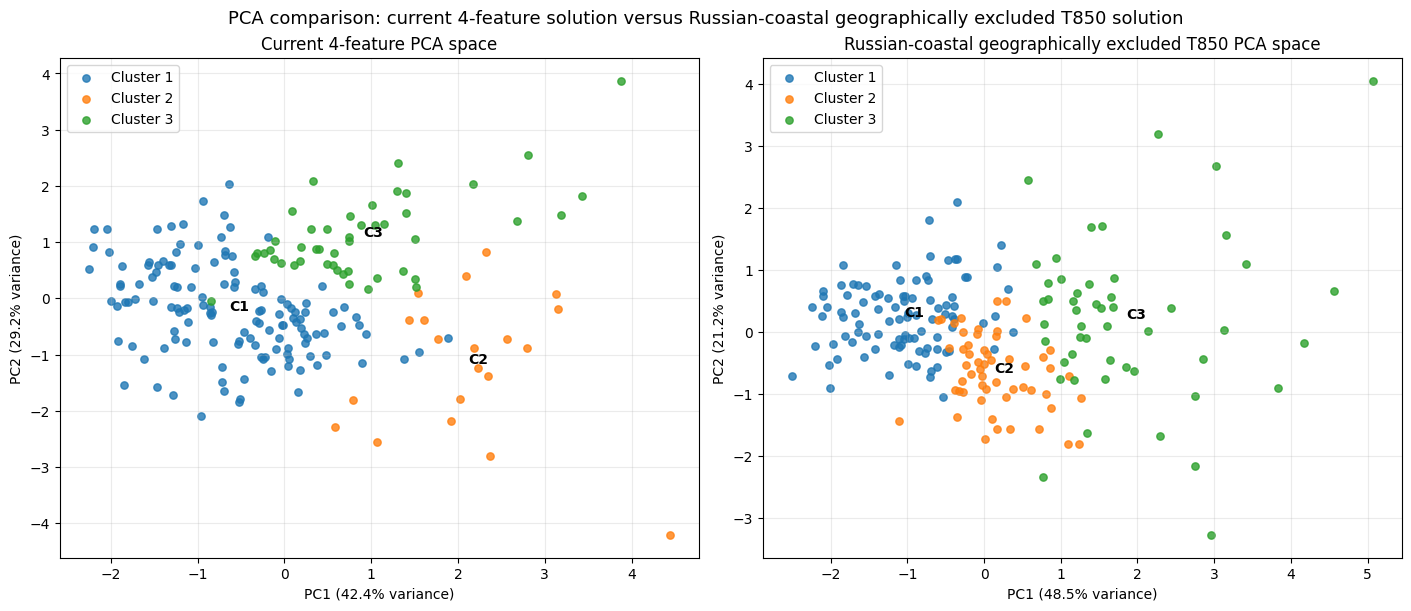

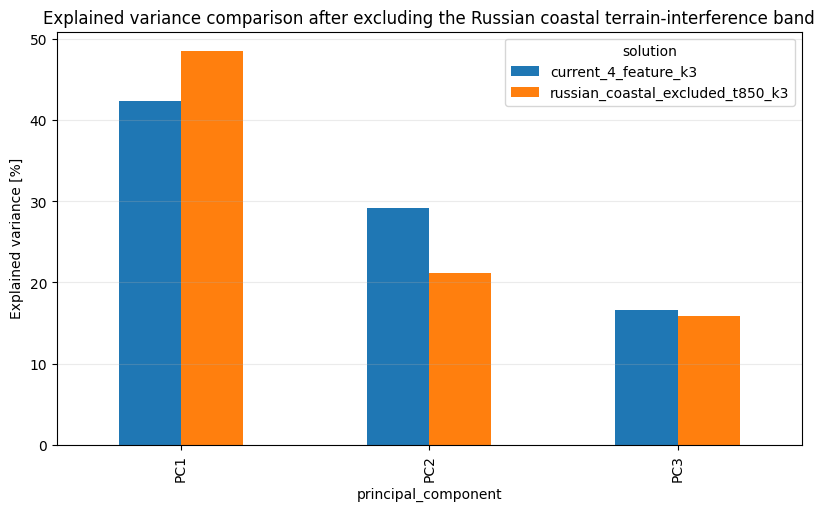

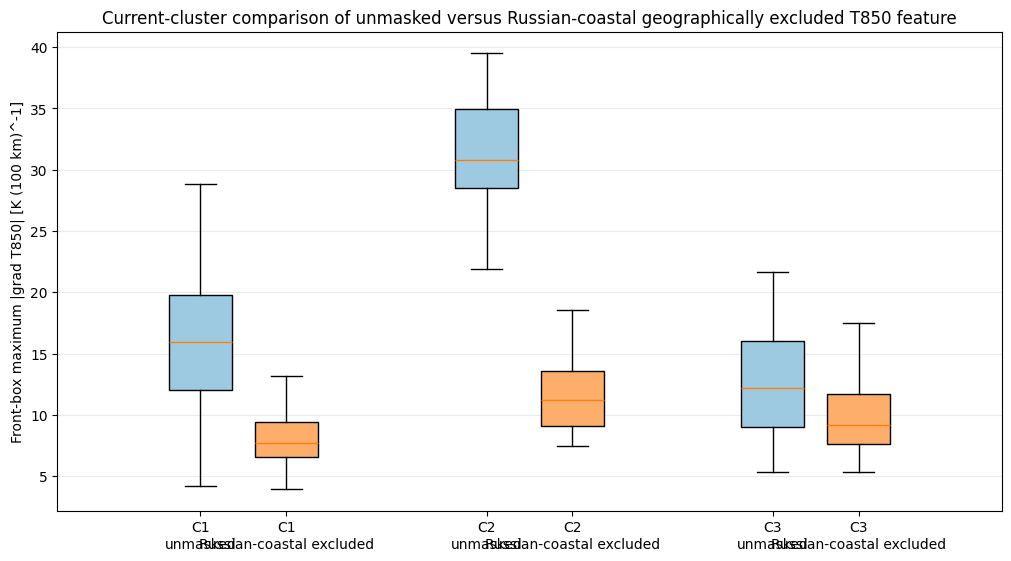

Saved Russian-coastal geographically excluded T850 sensitivity plots


,plot,path
0,PCA scatter,outputs/verification/objective_subtype_t850_ru...
1,PCA variance comparison,outputs/verification/objective_subtype_t850_ru...
2,Current-cluster T850 unmasked versus Russian-c...,outputs/verification/objective_subtype_t850_ru...


In [8]:
cluster_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
plot_specs = [
    (
        axes[0],
        baseline_scores_df,
        current_cluster_labels.loc[baseline_scores_df.index].astype(int),
        baseline_variance_df,
        "Current 4-feature PCA space",
    ),
    (
        axes[1],
        excluded_scores_df,
        excluded_cluster_labels.loc[excluded_scores_df.index].astype(int),
        excluded_variance_df,
        "Russian-coastal geographically excluded T850 PCA space",
    ),
]

for ax, score_df, labels, variance_df, title in plot_specs:
    for cluster_id in sorted(labels.unique()):
        mask = labels == cluster_id
        ax.scatter(
            score_df.loc[mask, "PC1"],
            score_df.loc[mask, "PC2"],
            s=28,
            alpha=0.8,
            color=cluster_colors.get(int(cluster_id), "gray"),
            label=f"Cluster {int(cluster_id)}",
        )
        centroid_x = float(score_df.loc[mask, "PC1"].mean())
        centroid_y = float(score_df.loc[mask, "PC2"].mean())
        ax.text(centroid_x, centroid_y, f"C{int(cluster_id)}", fontsize=10, weight="bold")
    pc1_pct = float(variance_df.loc[variance_df["principal_component"] == "PC1", "explained_variance_percent"].iloc[0])
    pc2_pct = float(variance_df.loc[variance_df["principal_component"] == "PC2", "explained_variance_percent"].iloc[0])
    ax.set_xlabel(f"PC1 ({pc1_pct:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pc2_pct:.1f}% variance)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

fig.suptitle(
    "PCA comparison: current 4-feature solution versus Russian-coastal geographically excluded T850 solution",
    fontsize=13,
)
if SAVE_PLOTS:
    fig.savefig(PCA_SCATTER_PATH, dpi=180, bbox_inches="tight")
    maybe_copy_to_drive(PCA_SCATTER_PATH, verbose=False)
plt.show()

variance_fig, variance_ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
variance_pivot = combined_variance_df.pivot(index="principal_component", columns="solution", values="explained_variance_percent")
variance_pivot.plot(kind="bar", ax=variance_ax)
variance_ax.set_ylabel("Explained variance [%]")
variance_ax.set_title("Explained variance comparison after excluding the Russian coastal terrain-interference band")
variance_ax.grid(axis="y", alpha=0.25)
if SAVE_PLOTS:
    variance_fig.savefig(PCA_VARIANCE_PLOT_PATH, dpi=180, bbox_inches="tight")
    maybe_copy_to_drive(PCA_VARIANCE_PLOT_PATH, verbose=False)
plt.show()

plot_feature_df = excluded_event_feature_df.copy()
plot_feature_df["current_cluster_id"] = plot_feature_df["current_cluster_id"].astype(int)
plot_feature_df["current_cluster_label"] = plot_feature_df["current_cluster_id"].map(current_cluster_label_lookup)
plot_feature_df = plot_feature_df.sort_values("current_cluster_id")
positions = []
labels = []
boxplot_data = []
colors = []
for cluster_id in sorted(plot_feature_df["current_cluster_id"].unique()):
    cluster_subset = plot_feature_df.loc[plot_feature_df["current_cluster_id"] == cluster_id]
    positions.extend([cluster_id - 0.15, cluster_id + 0.15])
    labels.extend([f"C{cluster_id}\nunmasked", f"C{cluster_id}\nRussian-coastal excluded"])
    boxplot_data.extend([
        cluster_subset["unmasked_t850_feature"].dropna().values,
        cluster_subset[EXCLUDED_FEATURE_COLUMN].dropna().values,
    ])
    colors.extend(["#9ecae1", "#fdae6b"])

compare_fig, compare_ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
box = compare_ax.boxplot(boxplot_data, positions=positions, widths=0.22, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
compare_ax.set_xticks(positions)
compare_ax.set_xticklabels(labels)
compare_ax.set_ylabel("Front-box maximum |grad T850| [K (100 km)^-1]")
compare_ax.set_title("Current-cluster comparison of unmasked versus Russian-coastal geographically excluded T850 feature")
compare_ax.grid(axis="y", alpha=0.25)
if SAVE_PLOTS:
    compare_fig.savefig(T850_COMPARE_PLOT_PATH, dpi=180, bbox_inches="tight")
    maybe_copy_to_drive(T850_COMPARE_PLOT_PATH, verbose=False)
plt.show()

print("Saved Russian-coastal geographically excluded T850 sensitivity plots")
display(pd.DataFrame({
    "plot": ["PCA scatter", "PCA variance comparison", "Current-cluster T850 unmasked versus Russian-coastal excluded boxplots"],
    "path": [str(PCA_SCATTER_PATH), str(PCA_VARIANCE_PLOT_PATH), str(T850_COMPARE_PLOT_PATH)],
}))


### How to read the result

- If switching is smaller than the drop-`T850` test and the Russian-coastal geographically excluded `T850` `k = 3` solution still looks close to the current one, then the exclusion boxes are removing the Russian coastal terrain interference without breaking the subtype story.
- If switching becomes large or the refined split collapses, then the present `k = 3` story is still too dependent on the terrain-linked part of the frontality metric.
- This notebook changes **only** the `T850` frontality metric so that the effect of the explicit geographic exclusions can be isolated cleanly.
